In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import fft, signal, stats
from scipy.signal import (
    butter,
    filtfilt,
    firwin,
    freqz,
    get_window,
    lfilter,
    periodogram,
)

In [26]:
f = 1 / 50
x = np.linspace(0, 1000, 1000)
y = stats.distributions.norm.rvs(size=len(x)) + np.sin(x * f * 2 * np.pi)

# butter = signal.butter(8, 0.125, output='sos')
# y = signal.sosfilt(butter, x)

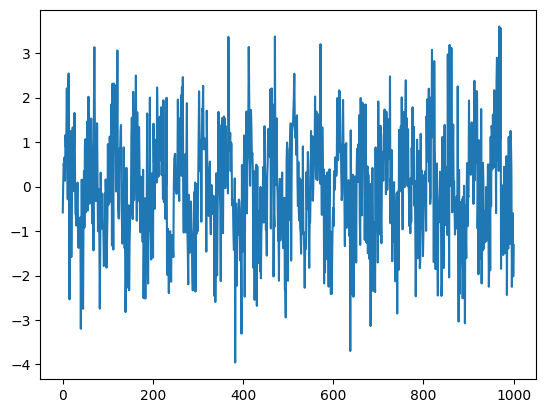

In [27]:
plt.plot(x, y, label="Original Signal")

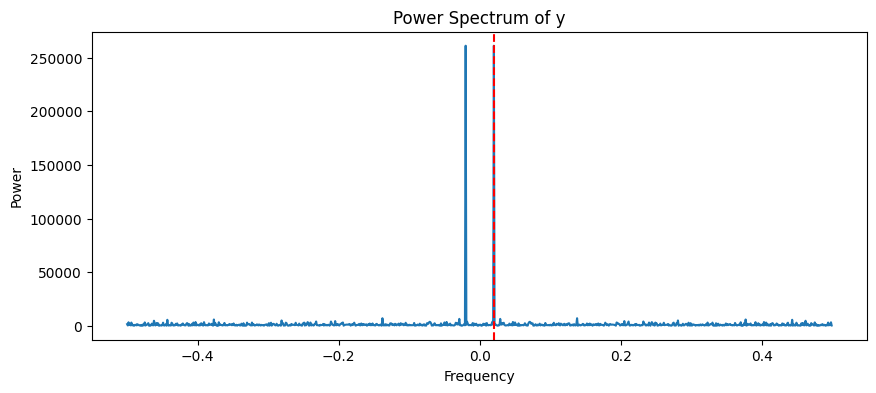

In [28]:
# Compute the FFT of y
y_fft = fft.fft(y)
power_spectrum = np.abs(y_fft) ** 2
freqs = fft.fftfreq(len(y))

# Plot the power spectrum
plt.figure(figsize=(10, 4))
plt.plot(fft.fftshift(freqs), fft.fftshift(power_spectrum))
plt.title("Power Spectrum of y")
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.axvline(f, color="red", linestyle="--", label="Signal Frequency (1/10 Hz)")
plt.show()

In [ ]:
butter_sos = signal.butter(8, 1 / 20, btype="lp", output="sos")
y_filt = signal.sosfilt(butter_sos, y)
y_filtfilt = signal.sosfiltfilt(butter_sos, y)

(700.0, 1000.0)

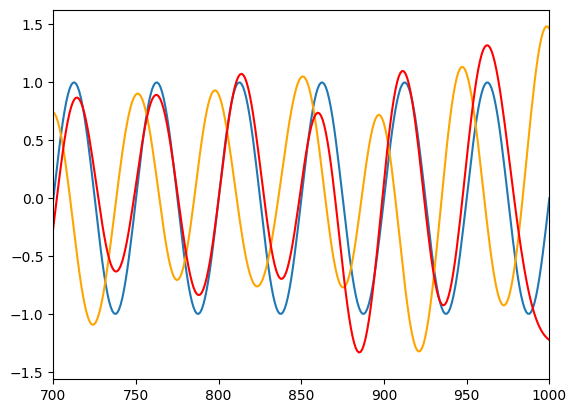

In [54]:
plt.plot(x, np.sin(x * f * 2 * np.pi))
plt.plot(x, y_filt, label="Filtered Signal", color="orange")
plt.plot(x, y_filtfilt, label="Filtered Signal", color="red")
plt.xlim(700, 1000)

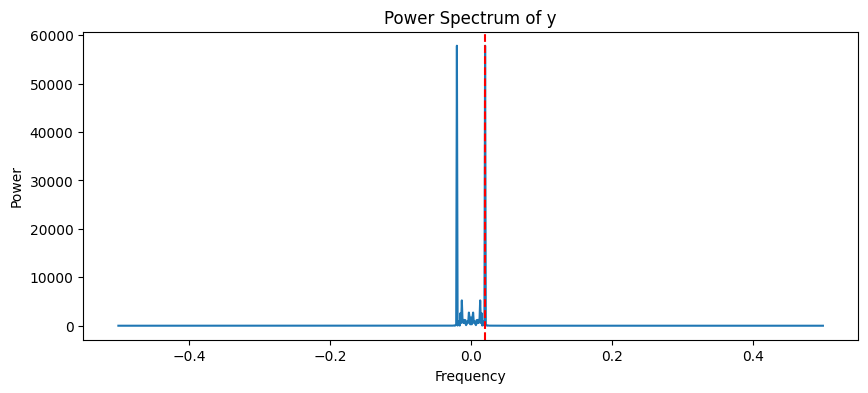

In [7]:
# Compute the FFT of y
y_fft = fft.fft(y_filt)
power_spectrum = np.abs(y_fft) ** 2
freqs = fft.fftfreq(len(y))

# Plot the power spectrum
plt.figure(figsize=(10, 4))
plt.plot(fft.fftshift(freqs), fft.fftshift(power_spectrum))
plt.title("Power Spectrum of y")
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.axvline(f, color="red", linestyle="--", label="Signal Frequency (1/10 Hz)")
plt.show()

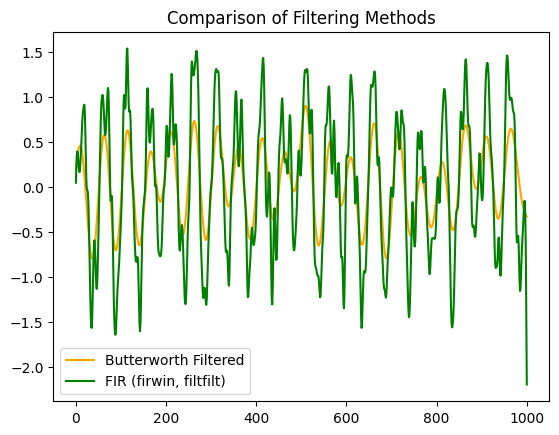

In [17]:
# Design an FIR filter using firwin
numtaps = 10
cutoff = 1 / 10  # same as Butterworth for comparison
fir_coeff = signal.firwin(numtaps, cutoff, fs=1)

# Apply the FIR filter using filtfilt for zero-phase filtering
y_fir_filt = signal.filtfilt(fir_coeff, [1.0], y)

# plt.plot(x, y, label='Original Signal')
plt.plot(x, y_filt, label="Butterworth Filtered", color="orange")
plt.plot(x, y_fir_filt, label="FIR (firwin, filtfilt)", color="green")
plt.legend()
plt.title("Comparison of Filtering Methods")
plt.show()

C:\Users\asche\AppData\Local\Temp\ipykernel_4040\3164204493.py:9: RuntimeWarning: invalid value encountered in scalar divide
  amp = np.abs(filtered).max() / np.abs(test_sin).max()


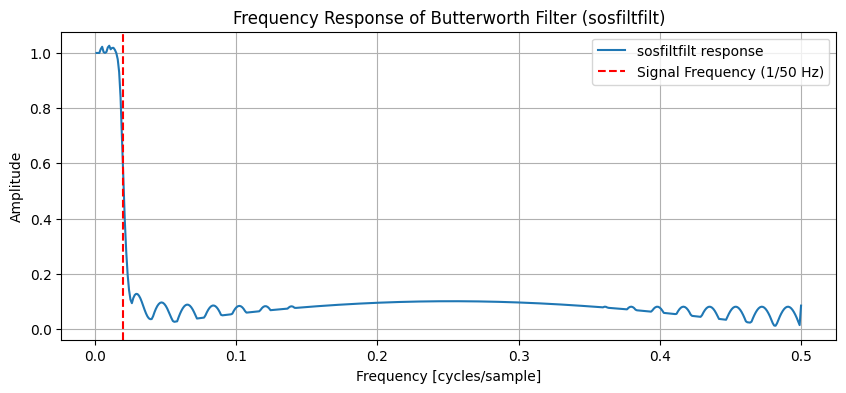

In [ ]:
# Frequency response of sosfiltfilt (zero-phase) by simulation
freqs = np.linspace(0, 0.5, 500)
response = []

for freq in freqs:
    t = np.arange(0, 1000)
    test_sin = np.sin(2 * np.pi * freq * t)
    filtered = signal.sosfiltfilt(butter_sos, test_sin)
    amp = np.abs(filtered).max() / np.abs(test_sin).max()
    response.append(amp)

plt.figure(figsize=(10, 4))
plt.plot(freqs, response, label="sosfiltfilt response")
plt.title("Frequency Response of Butterworth Filter (sosfiltfilt)")
plt.xlabel("Frequency [cycles/sample]")
plt.ylabel("Amplitude")
plt.axvline(f, color="red", linestyle="--", label="Signal Frequency (1/50 Hz)")
plt.legend()
plt.grid()
plt.show()

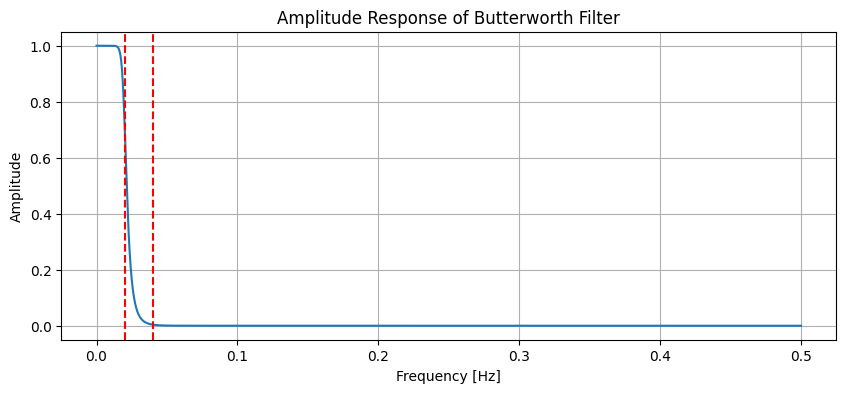

In [ ]:
w, h = signal.freqz_sos(butter_sos, worN=2000, fs=1)
plt.figure(figsize=(10, 4))
plt.plot(w, np.abs(h))
plt.title("Amplitude Response of Butterworth Filter")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.grid()
plt.axvline(f, color="red", linestyle="--", label="Signal Frequency (1/10 Hz)")
plt.axvline(1 / 25, color="red", linestyle="--", label="Signal Frequency (1/10 Hz)")
plt.show()

In [ ]:
w, h = signal.freqz_sos(butter_sos, worN=2000, fs=2)
half_amp = 1 / np.sqrt(2)
idx = np.argmin(np.abs(np.abs(h) - half_amp))
cutoff_freq = w[idx]  # now in units of Nyquist (0.5 cycles/sample)

print(
    f"Half amplitude (-3dB) cutoff frequency (normalized to Nyquist): {cutoff_freq:.3f}",
)

Half amplitude (-3dB) cutoff frequency (normalized to Nyquist): 0.200


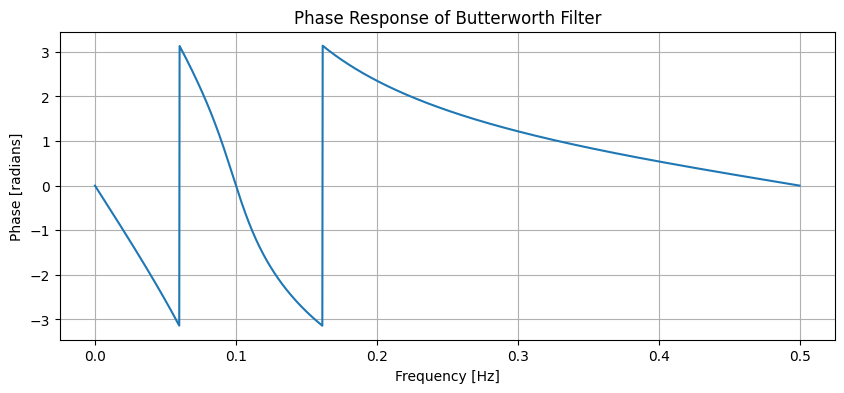

In [ ]:
w, h = signal.freqz_sos(butter_sos, worN=2000, fs=1)
plt.figure(figsize=(10, 4))
plt.plot(w, np.angle(h))
plt.title("Phase Response of Butterworth Filter")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Phase [radians]")
plt.grid()
plt.show()

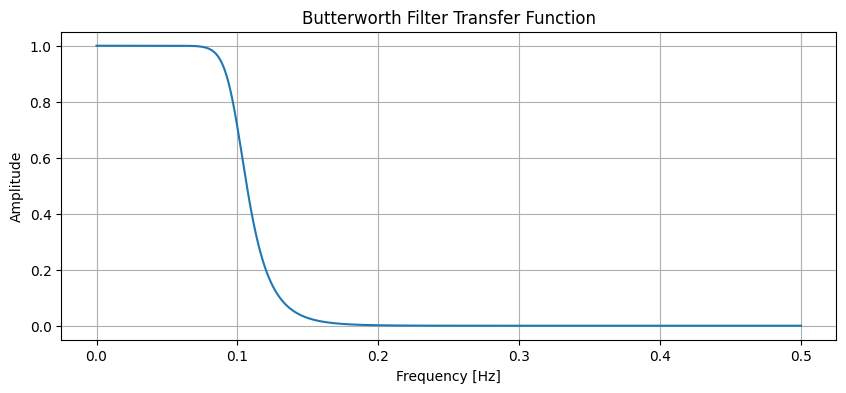

In [ ]:
w, h = signal.freqz_sos(butter_sos, worN=2000, fs=1)
plt.figure(figsize=(10, 4))
plt.plot(w, np.abs(h))
plt.title("Butterworth Filter Transfer Function")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

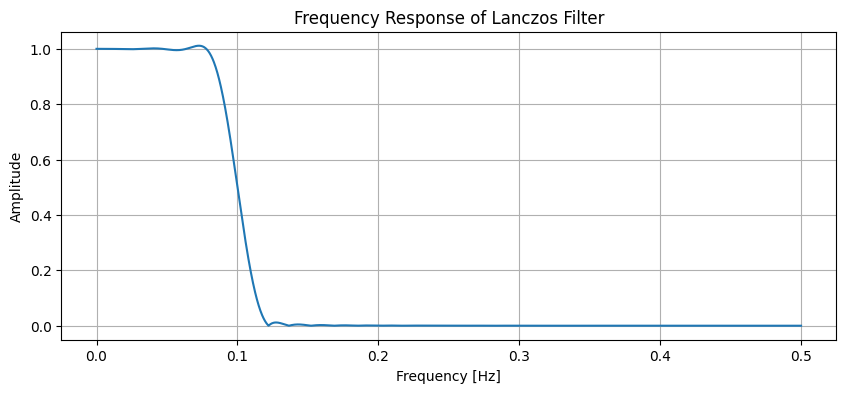

In [89]:
# Define a Lanczos filter (windowed sinc)
def lanczos_filter(M, fc):
    n = np.arange(-M, M + 1)
    h = np.sinc(2 * fc * n) * np.sinc(n / M)
    h /= np.sum(h)
    return h


M = 30  # filter half-width
fc = 0.1  # normalized cutoff (0 < fc < 0.5)
h = lanczos_filter(M, fc)

w, h_freq = signal.freqz(h, worN=2000, fs=1)
plt.figure(figsize=(10, 4))
plt.plot(w, np.abs(h_freq))
plt.title("Frequency Response of Lanczos Filter")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

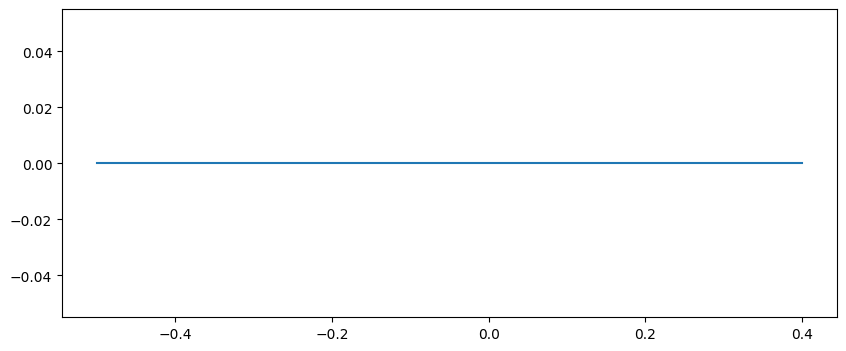

In [97]:
fft_b = fft.fft(signal.windows.boxcar(10))
plt.figure(figsize=(10, 4))
plt.plot(fft.fftshift(fft.fftfreq(10)), (fft.fftshift(fft_b.imag)))

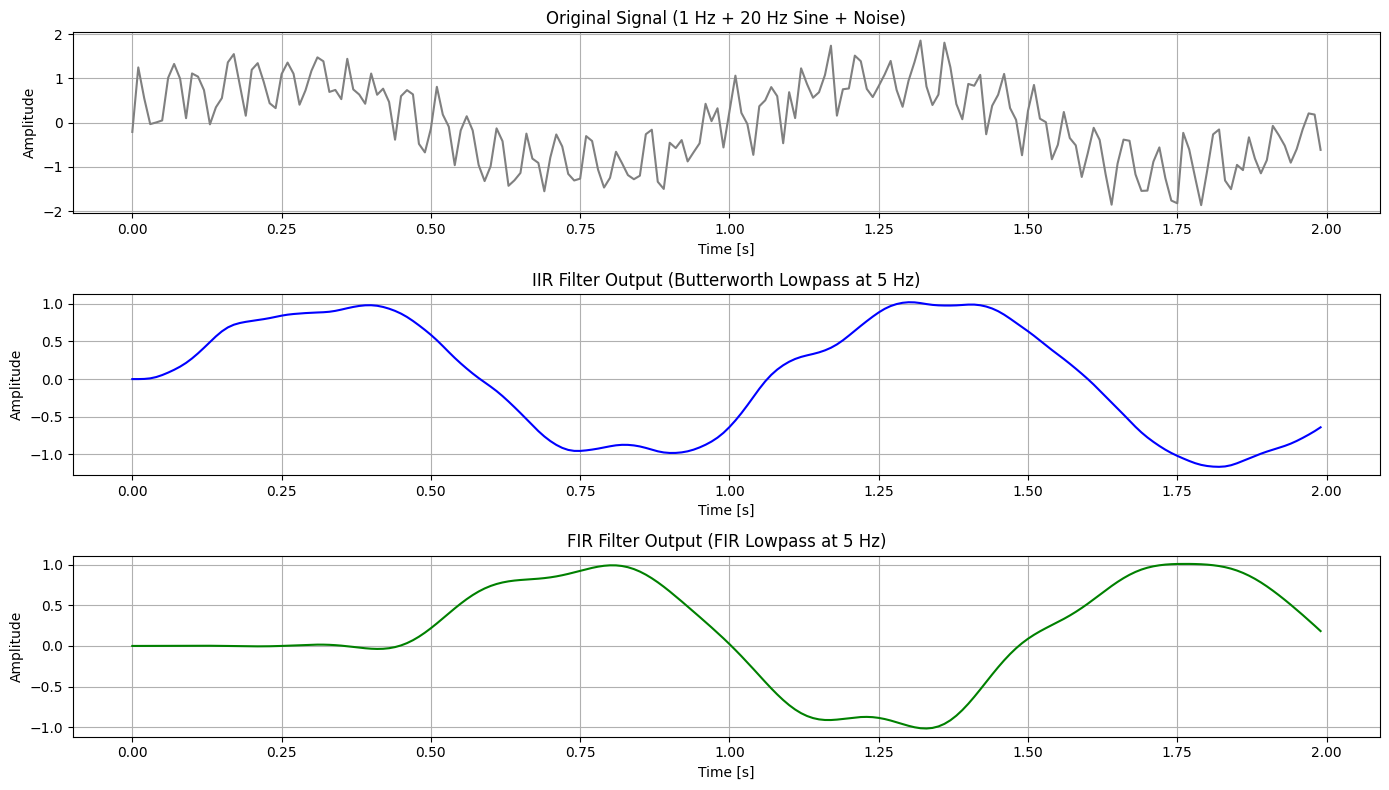

In [ ]:
# Generate sample signal: 1 Hz + 20 Hz sine waves with noise
fs = 100.0  # Sample rate (Hz)
t = np.arange(0, 2.0, 1 / fs)  # 2 seconds of data
signal = np.sin(2 * np.pi * 1 * t) + 0.5 * np.sin(2 * np.pi * 20 * t) + 0.3 * np.random.randn(len(t))

# IIR Filter Design: Butterworth lowpass at 5 Hz
b_iir, a_iir = butter(N=4, Wn=5, btype="low", fs=fs)
filtered_iir = lfilter(b_iir, a_iir, signal)

# FIR Filter Design: lowpass at 5 Hz
numtaps = 101
b_fir = firwin(numtaps=numtaps, cutoff=5, fs=fs)
filtered_fir = lfilter(b_fir, [1.0], signal)

# Plotting
plt.figure(figsize=(14, 8))

plt.subplot(3, 1, 1)
plt.plot(t, signal, label="Original Signal", color="gray")
plt.title("Original Signal (1 Hz + 20 Hz Sine + Noise)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, filtered_iir, label="IIR Filtered", color="blue")
plt.title("IIR Filter Output (Butterworth Lowpass at 5 Hz)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, filtered_fir, label="FIR Filtered", color="green")
plt.title("FIR Filter Output (FIR Lowpass at 5 Hz)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

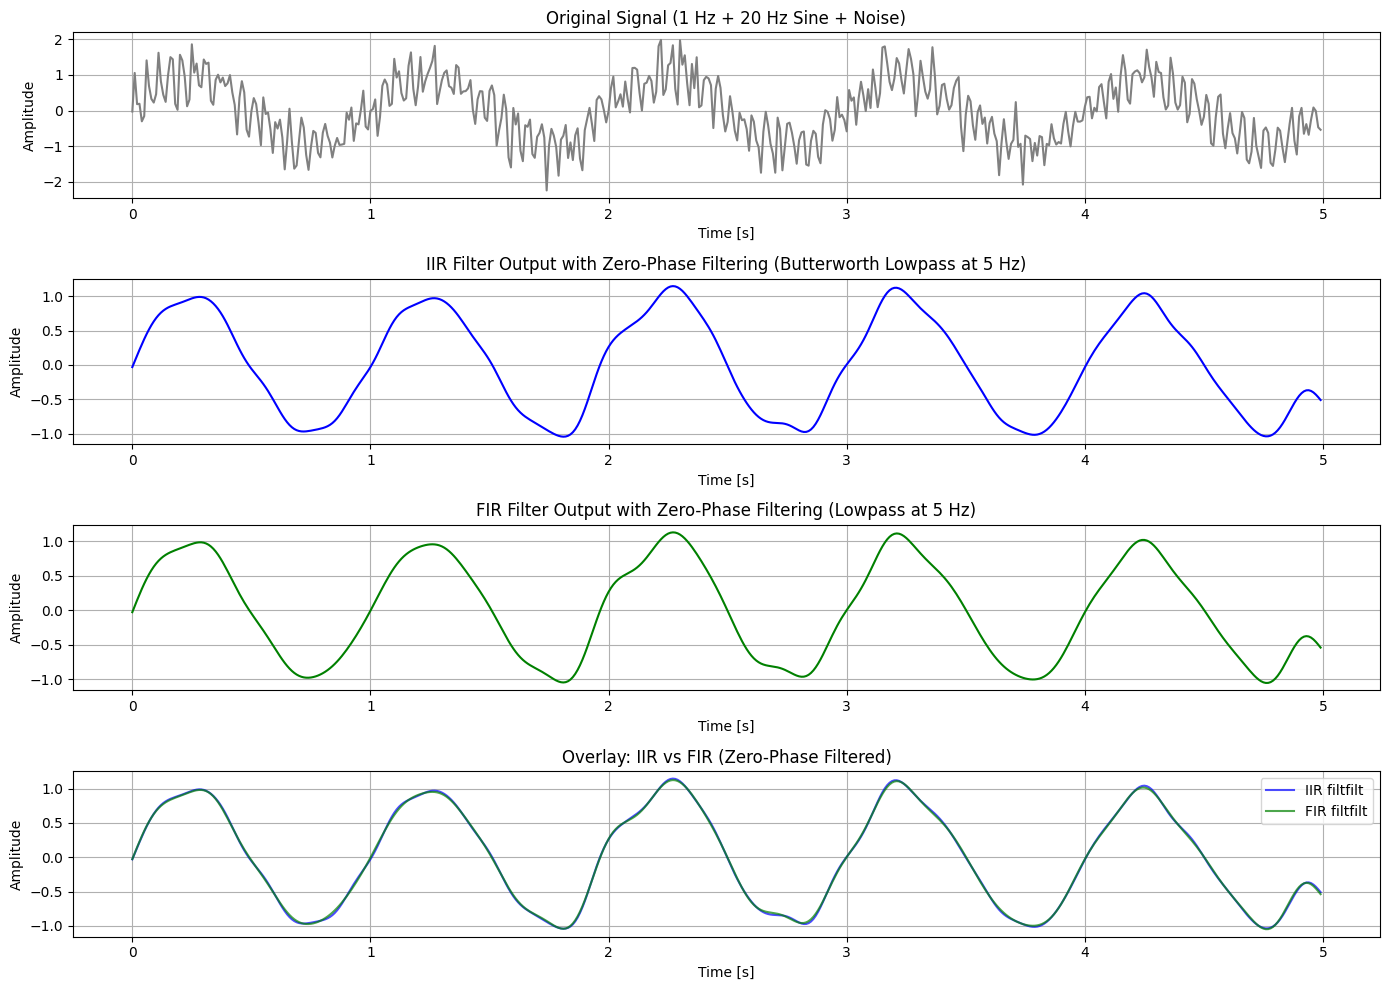

In [ ]:
# Extend signal duration to 5 seconds (500 samples)
t_long = np.arange(0, 5.0, 1 / fs)
signal_long = (
    np.sin(2 * np.pi * 1 * t_long) + 0.5 * np.sin(2 * np.pi * 20 * t_long) + 0.3 * np.random.randn(len(t_long))
)

# Apply zero-phase filtering using filtfilt
filtered_iir_filtfilt_long = filtfilt(b_iir, a_iir, signal_long)
filtered_fir_filtfilt_long = filtfilt(b_fir, [1.0], signal_long)

# Plotting comparison
plt.figure(figsize=(14, 10))

plt.subplot(4, 1, 1)
plt.plot(t_long, signal_long, label="Original Signal", color="gray")
plt.title("Original Signal (1 Hz + 20 Hz Sine + Noise)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(t_long, filtered_iir_filtfilt_long, label="IIR with filtfilt", color="blue")
plt.title("IIR Filter Output with Zero-Phase Filtering (Butterworth Lowpass at 5 Hz)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(t_long, filtered_fir_filtfilt_long, label="FIR with filtfilt", color="green")
plt.title("FIR Filter Output with Zero-Phase Filtering (Lowpass at 5 Hz)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(
    t_long,
    filtered_iir_filtfilt_long,
    label="IIR filtfilt",
    color="blue",
    alpha=0.7,
)
plt.plot(
    t_long,
    filtered_fir_filtfilt_long,
    label="FIR filtfilt",
    color="green",
    alpha=0.7,
)
plt.title("Overlay: IIR vs FIR (Zero-Phase Filtered)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

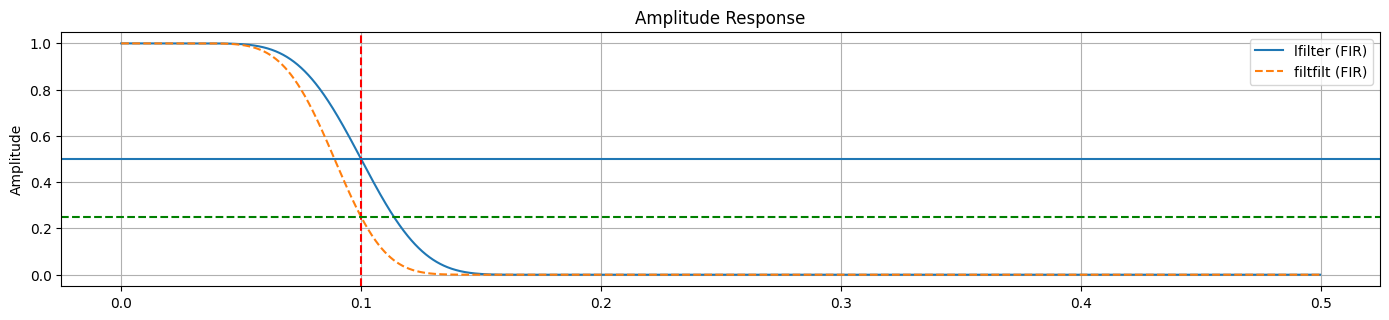

In [ ]:
# Compute frequency response for lfilter (FIR)
w, h_lfilter = freqz(firwin(51, 1 / 10, fs=1, window=("kaiser", 10)), worN=2000, fs=1)
# Compute frequency response for filtfilt (FIR, squared magnitude, doubled phase)
h_filtfilt = h_lfilter**2  # filtfilt applies filter twice (zero-phase)

plt.figure(figsize=(14, 6))

# Amplitude response
plt.subplot(2, 1, 1)
plt.plot(w, np.abs(h_lfilter), label="lfilter (FIR)")
plt.plot(w, np.abs(h_filtfilt), label="filtfilt (FIR)", linestyle="--")
plt.title("Amplitude Response")
plt.ylabel("Amplitude")
plt.legend()
plt.axvline(1 / 10, color="red", linestyle="--", label="Cutoff Frequency (1/10 Hz)")
plt.axhline(1 / 2)
plt.axhline(1 / 2**2, color="green", linestyle="--", label="-3dB Point")
plt.grid()

# # Phase response
# plt.subplot(2, 1, 2)
# plt.plot(w, np.angle(h_lfilter), label='lfilter (FIR)')
# plt.plot(w, np.angle(h_filtfilt), label='filtfilt (FIR)', linestyle='--')
# plt.title('Phase Response')
# plt.xlabel('Frequency [Hz]')
# plt.ylabel('Phase [radians]')
# plt.legend()
# plt.grid()

plt.tight_layout()
plt.show()

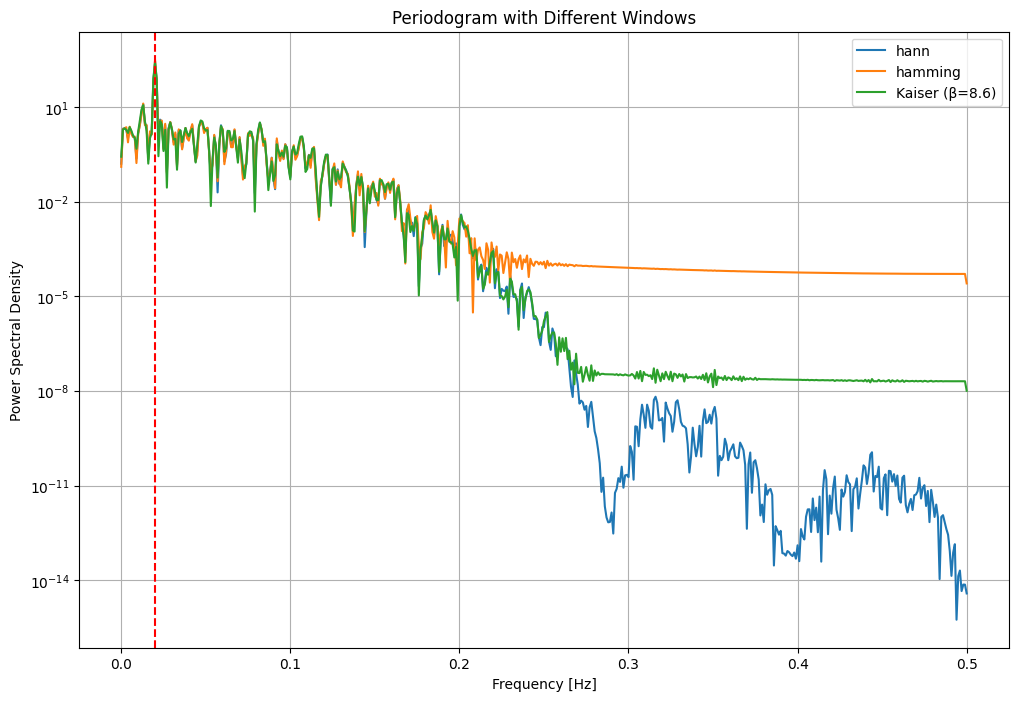

In [ ]:
windows = ["hann", "hamming", ("kaiser", 8.6)]
fs = 1  # Assuming sample spacing is 1

plt.figure(figsize=(12, 8))
for win in windows:
    f, Pxx = periodogram(
        y_fir_filt,
        fs=fs,
        window=get_window(win, len(y_fir_filt)),
        scaling="density",
    )
    label = win if isinstance(win, str) else f"{win[0].capitalize()} (β={win[1]})"
    plt.semilogy(f, Pxx, label=label)

plt.title("Periodogram with Different Windows")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power Spectral Density")
plt.legend()
plt.axvline(1 / 50, color="red", linestyle="--", label="Signal Frequency (1/50 Hz)")
plt.grid(True)
plt.show()